# Bar Detection on IBCS Charts

Point this notebook at any image in `Dataset/Compliant/`. It runs a 3-step OpenCV pipeline:

1. **Isolate by feature** &mdash; build three independent binary masks:
    - Mask A: pure black (solid AC bars)
    - Mask B: mid-grey (PY / stacked greys)
    - Mask C: hatched / diagonal-stripe regions (FC bars)
2. **Fill empty bars** &mdash; Canny edges, find rectangular contours, redraw them as solid filled rectangles so outlined-only bars become measurable blocks.
3. **Combine, project, locate** &mdash; OR all masks together, show X/Y projection profiles as diagnostics, then connected-components to grab individual bars and draw bounding boxes.

Single class (`"bar"`), visualization-only &mdash; no labels written to disk.

## Cell 1 &mdash; Setup & imports

In [73]:
%matplotlib inline
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt


def show(img, title="", cmap=None, figsize=(10, 6)):
    """Display a single image (handles RGB and single-channel masks)."""
    plt.figure(figsize=figsize)
    if img.ndim == 2 and cmap is None:
        cmap = "gray"
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()


def show_grid(images, titles, cols=3, figsize=(15, 10)):
    """Display several images in a grid."""
    rows = int(np.ceil(len(images) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()
    for ax, im, t in zip(axes, images, titles):
        cmap = "gray" if im.ndim == 2 else None
        ax.imshow(im, cmap=cmap)
        ax.set_title(t)
        ax.axis("off")
    for ax in axes[len(images):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

## Cell 2 &mdash; Parameters (the one cell you tweak)

Change `IMAGE_PATH` to point at any chart. Two important controls beyond raw thresholds:

- **`INVERT_INPUT`** &mdash; flips the grayscale before any masking. Turn on for dark-themed charts, or when hatching texture is drowning Mask A.
- **`MIN_AREA_FRACTION` + `MIN_FILL_RATIO`** &mdash; a *dynamic* size filter that keeps only components that are (a) big relative to the largest survivor and (b) rectangular enough (filled / bbox-area). This auto-scales to image resolution and chart density &mdash; no more hard-coded "150 pixels".

In [74]:
IMAGE_PATH = Path("../Dataset/Compliant/6.png")

# --- Preprocessing -----------------------------------------------------------
# Flip the grayscale before any thresholding. Turn this ON when the chart has
# a dark background, or when Mask A is overwhelmed by hatching texture and
# you'd rather pick up "bar envelopes" via the inverted thresholds instead.
INVERT_INPUT = True

# --- Mask A / B intensity thresholds -----------------------------------------
BLACK_MAX = 60
GREY_RANGE = (80, 190)

# --- Edge / hatch detection --------------------------------------------------
CANNY_LOW = 50
CANNY_HIGH = 150

# --- Dynamic size + rectangularity filter ------------------------------------
# We favour relatively *big*, *rectangular* shapes. A component must
#   (a) clear an absolute pixel floor,
#   (b) be >= MIN_AREA_FRACTION of the LARGEST surviving candidate, and
#   (c) fill at least MIN_FILL_RATIO of its bounding box (rectangularity).
MIN_AREA_FLOOR = 100
MIN_AREA_FRACTION = 0.05
MIN_FILL_RATIO = 0.75
MIN_BAR_W = 4
MIN_BAR_H = 4
MAX_ASPECT = 25.0

## Cell 3 &mdash; Load image

(grayscale inverted before thresholding)
Loaded 6.png  shape=(443, 575, 3)


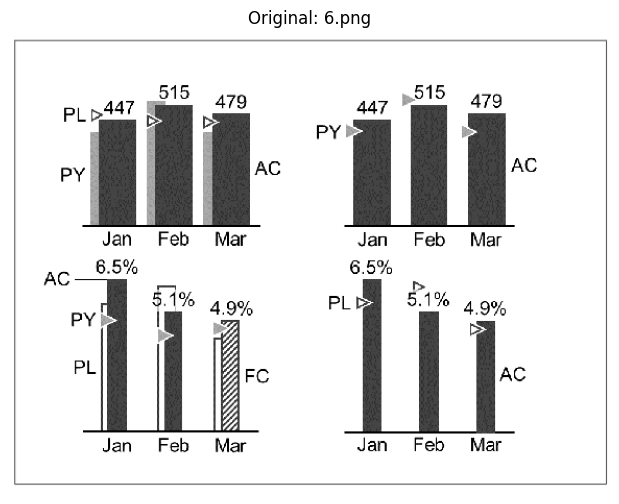

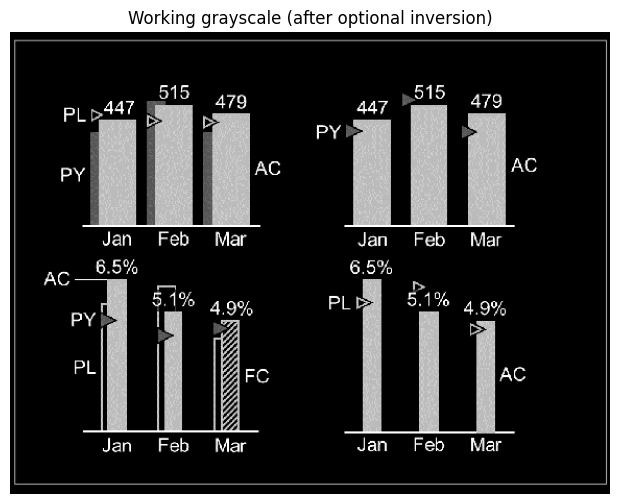

In [75]:
bgr = cv2.imread(str(IMAGE_PATH), cv2.IMREAD_COLOR)
if bgr is None:
    raise FileNotFoundError(f"Could not read image: {IMAGE_PATH.resolve()}")

rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

if INVERT_INPUT:
    gray = cv2.bitwise_not(gray)
    print("(grayscale inverted before thresholding)")

print(f"Loaded {IMAGE_PATH.name}  shape={rgb.shape}")
show(rgb, title=f"Original: {IMAGE_PATH.name}")
show(gray, title="Working grayscale (after optional inversion)")

## Cell 4 &mdash; Mask A: solid black bars

Catches solid AC bars (e.g. the highlighted Jan/Feb columns in `107.png`, the AC row in `109.png`).

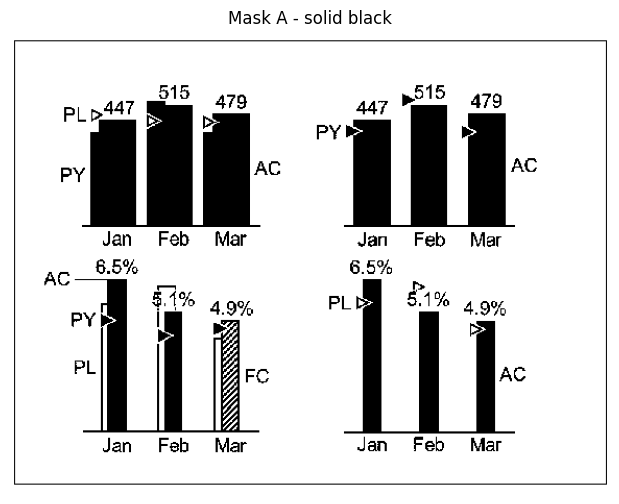

In [76]:
_, mask_a = cv2.threshold(gray, BLACK_MAX, 255, cv2.THRESH_BINARY_INV)
show(mask_a, title="Mask A - solid black")

## Cell 5 &mdash; Mask B: mid-grey bars

Catches PY bars and the lighter greys in stacked charts (e.g. `101.png`, `105.png`).

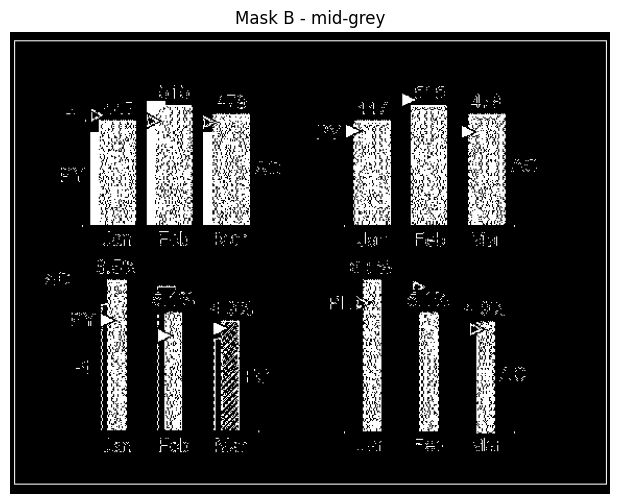

In [77]:
mask_b = cv2.inRange(gray, GREY_RANGE[0], GREY_RANGE[1])
show(mask_b, title="Mask B - mid-grey")

## Cell 6 &mdash; Mask C: hatched (diagonal-stripe) regions

Catches FC bars (e.g. `106.png`, `108.png`). The idea: hatching produces dense, oriented edges. Run Canny, then close along the diagonal so the stripes fuse into a solid blob.

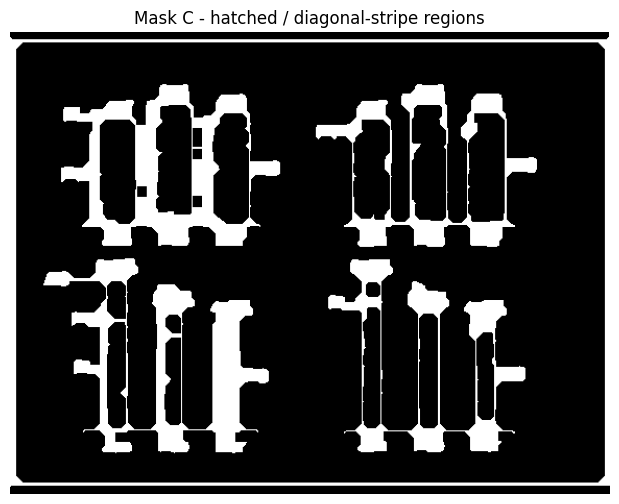

In [78]:
edges = cv2.Canny(gray, CANNY_LOW, CANNY_HIGH)

diag1 = np.array([[0, 0, 1], [0, 1, 0], [1, 0, 0]], dtype=np.uint8)
diag2 = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]], dtype=np.uint8)

closed1 = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, diag1, iterations=3)
closed2 = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, diag2, iterations=3)
hatch_raw = cv2.bitwise_or(closed1, closed2)

mask_c = cv2.morphologyEx(
    hatch_raw, cv2.MORPH_CLOSE,
    cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5)),
    iterations=2,
)

show(mask_c, title="Mask C - hatched / diagonal-stripe regions")

## Cell 7 &mdash; Step 2: fill the empty bars

Outlined-only bars (e.g. the red/green variance boxes in `100.png`, the &Delta;BU row in `109.png`, the PL columns in `107.png`) have no fill, so they don't show up in Masks A/B/C. We close their edge-loops, find rectangular contours, and **redraw them as solid filled rectangles** on a fresh mask.

Found 1 raw contours, kept 1 rectangular ones.


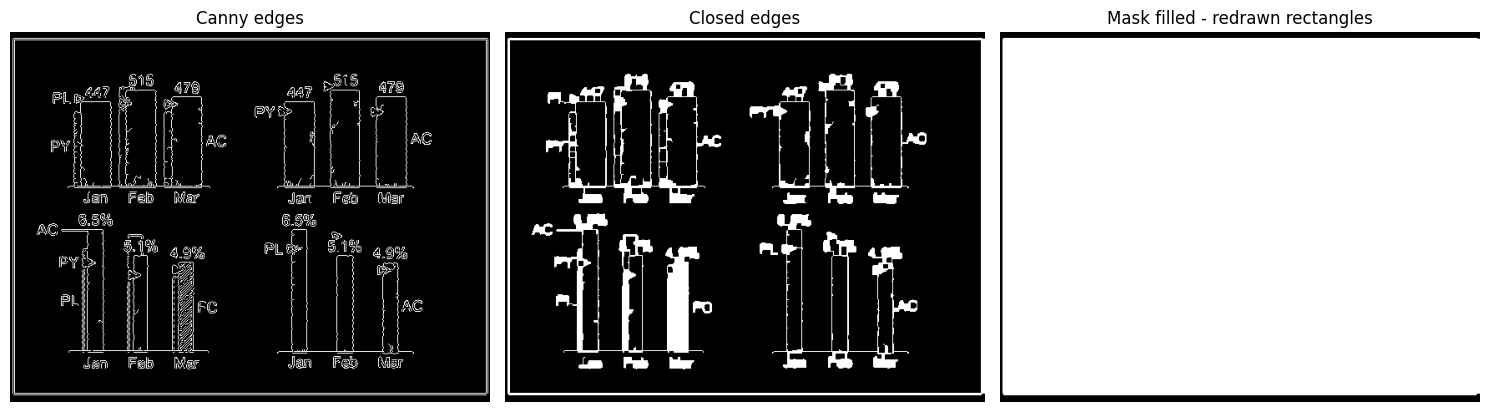

In [79]:
edges = cv2.Canny(gray, CANNY_LOW, CANNY_HIGH)
closed = cv2.morphologyEx(
    edges, cv2.MORPH_CLOSE,
    cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3)),
    iterations=2,
)

contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

kept = []
for c in contours:
    area = cv2.contourArea(c)
    if area < MIN_AREA_FLOOR:
        continue
    peri = cv2.arcLength(c, True)
    approx = cv2.approxPolyDP(c, 0.04 * peri, True)
    if not (4 <= len(approx) <= 8):
        continue
    x, y, w, h = cv2.boundingRect(c)
    rect_area = max(w * h, 1)
    if area / rect_area < MIN_FILL_RATIO:
        continue
    kept.append(c)

mask_filled = np.zeros_like(gray)
cv2.drawContours(mask_filled, kept, -1, 255, thickness=-1)

print(f"Found {len(contours)} raw contours, kept {len(kept)} rectangular ones.")
show_grid(
    [edges, closed, mask_filled],
    ["Canny edges", "Closed edges", "Mask filled - redrawn rectangles"],
    cols=3, figsize=(15, 5),
)

## Cell 8 &mdash; Combine all masks

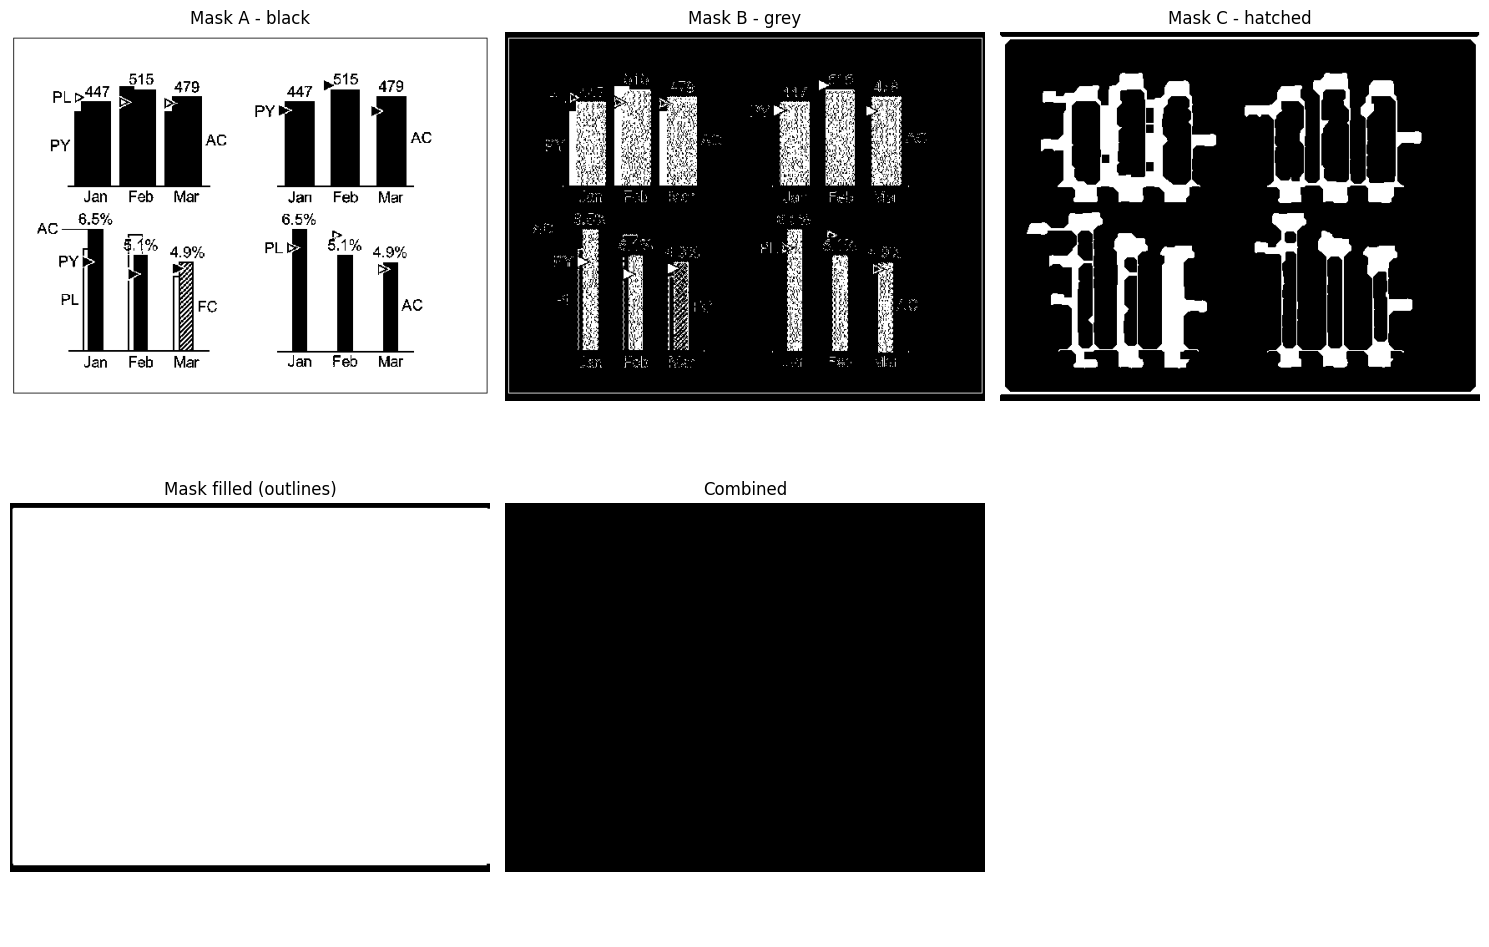

In [80]:
combined = cv2.bitwise_or(cv2.bitwise_or(mask_a, mask_b),
                          cv2.bitwise_or(mask_c, mask_filled))

k3 = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
combined = cv2.morphologyEx(combined, cv2.MORPH_CLOSE, k3, iterations=1)
combined = cv2.morphologyEx(combined, cv2.MORPH_OPEN,  k3, iterations=1)

show_grid(
    [mask_a, mask_b, mask_c, mask_filled, combined],
    ["Mask A - black", "Mask B - grey", "Mask C - hatched",
     "Mask filled (outlines)", "Combined"],
    cols=3, figsize=(15, 10),
)

## Cell 9 &mdash; Projection profiles (diagnostic)

Sum the combined mask along each axis. Peaks correspond to bar columns (X) and bar rows (Y). This is a sanity check &mdash; the actual segmentation happens in Cell 10.

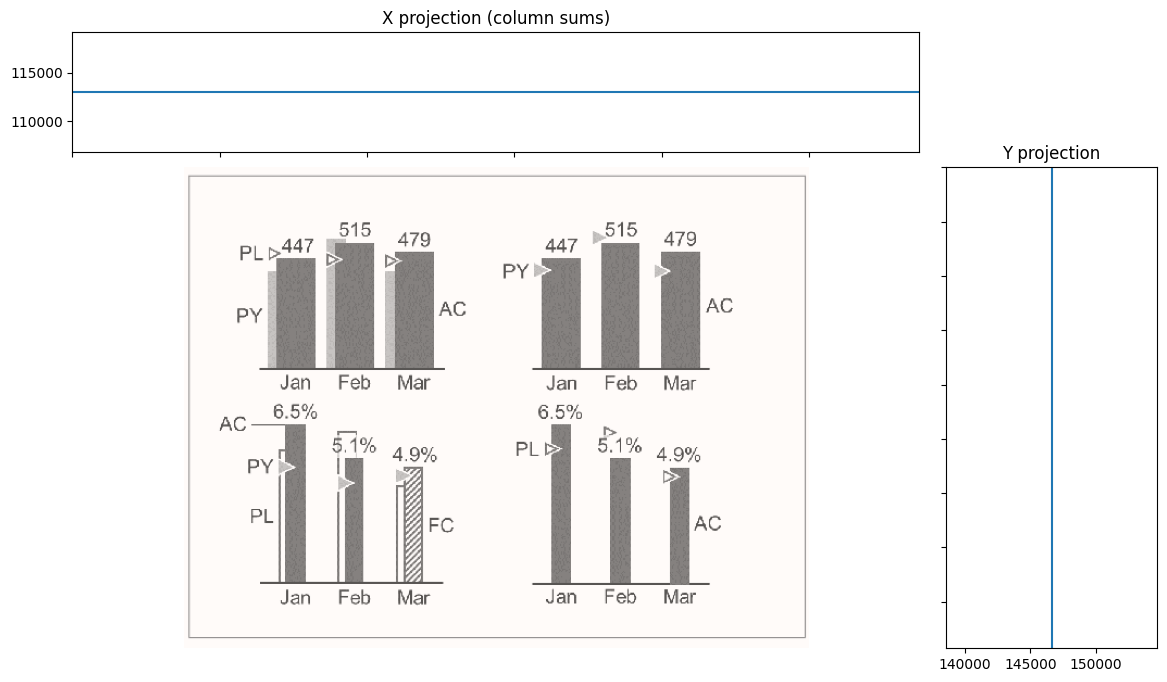

In [81]:
proj_x = combined.sum(axis=0)
proj_y = combined.sum(axis=1)

fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                      wspace=0.05, hspace=0.05)

ax_x = fig.add_subplot(gs[0, 0])
ax_x.plot(proj_x)
ax_x.set_xlim(0, combined.shape[1])
ax_x.set_title("X projection (column sums)")
ax_x.tick_params(labelbottom=False)

ax_img = fig.add_subplot(gs[1, 0])
ax_img.imshow(rgb)
ax_img.imshow(combined, cmap="Reds", alpha=0.35)
ax_img.axis("off")

ax_y = fig.add_subplot(gs[1, 1])
ax_y.plot(proj_y, np.arange(len(proj_y)))
ax_y.set_ylim(combined.shape[0], 0)
ax_y.set_title("Y projection")
ax_y.tick_params(labelleft=False)

plt.show()

## Cell 10 &mdash; Find individual bars

Connected components on the cleaned combined mask, filtered by area, minimum width/height, and aspect ratio to drop axis lines and text speckle. Connected components beats pure projection slicing for multi-panel charts like `100.png`, `105.png`, `108.png`.

In [82]:
num, labels, stats, _ = cv2.connectedComponentsWithStats(combined, connectivity=8)

# Pass 1: shape filters that don't depend on global stats yet.
candidates = []
for i in range(1, num):
    x, y, w, h, area = stats[i]
    if area < MIN_AREA_FLOOR or w < MIN_BAR_W or h < MIN_BAR_H:
        continue
    if max(w / h, h / w) > MAX_ASPECT:
        continue
    fill = area / max(w * h, 1)
    if fill < MIN_FILL_RATIO:
        continue
    candidates.append((int(x), int(y), int(w), int(h), int(area), float(fill)))

# Pass 2: dynamic size threshold relative to the biggest survivor, so the
# pipeline auto-scales to whatever resolution / chart density we're given.
if candidates:
    max_area = max(c[4] for c in candidates)
    dyn_threshold = max(MIN_AREA_FLOOR, MIN_AREA_FRACTION * max_area)
    bboxes = [
        (x, y, w, h)
        for x, y, w, h, a, f in candidates
        if a >= dyn_threshold
    ]
    print(
        f"Detected {len(bboxes)} bars  "
        f"(kept {len(bboxes)}/{len(candidates)} candidates; "
        f"max_area={max_area}, dynamic_min_area={int(dyn_threshold)})"
    )
else:
    bboxes = []
    print("No candidates survived the floor / rectangularity filter -- "
          "try lowering MIN_AREA_FLOOR / MIN_FILL_RATIO or toggling INVERT_INPUT.")

Detected 1 bars  (kept 1/1 candidates; max_area=254725, dynamic_min_area=12736)


## Cell 11 &mdash; Draw bounding boxes

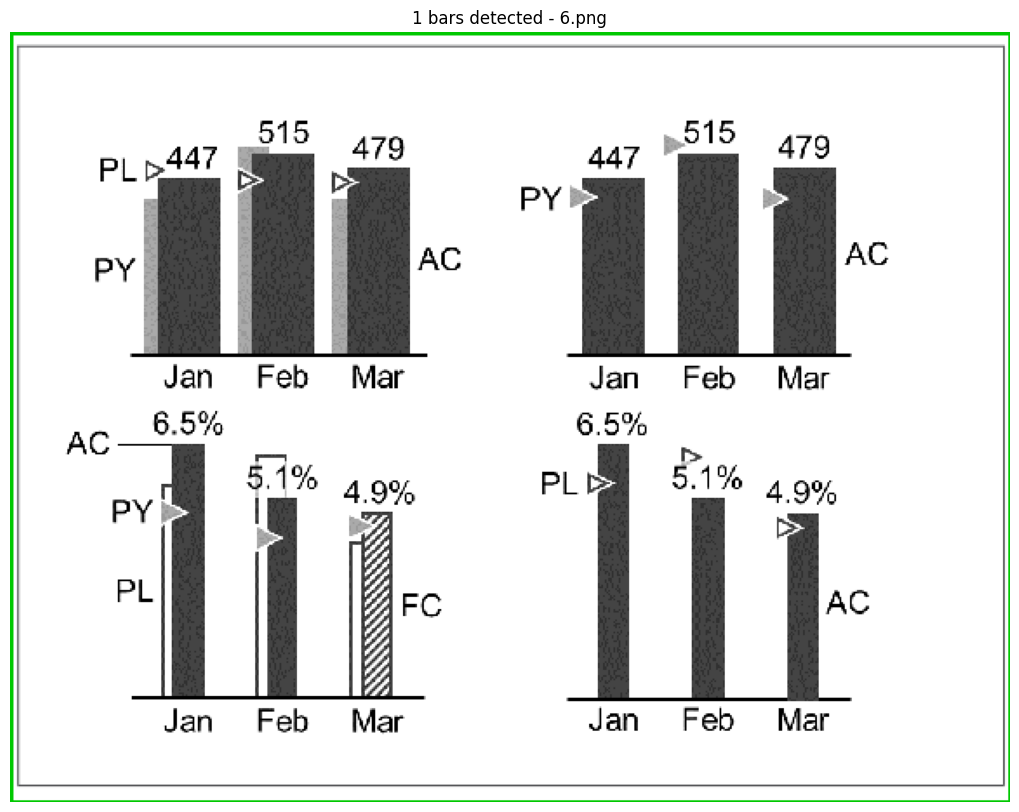

In [83]:
overlay = rgb.copy()
for x, y, w, h in bboxes:
    cv2.rectangle(overlay, (x, y), (x + w, y + h), (0, 200, 0), 2)

show(overlay, title=f"{len(bboxes)} bars detected - {IMAGE_PATH.name}",
     figsize=(14, 10))

## Cell 12 &mdash; One-shot function

Wraps the full pipeline so you can try other images quickly:

```python
detect_bars("../Dataset/Compliant/100.png")
detect_bars("../Dataset/Compliant/105.png", grey_range=(70, 200))
```

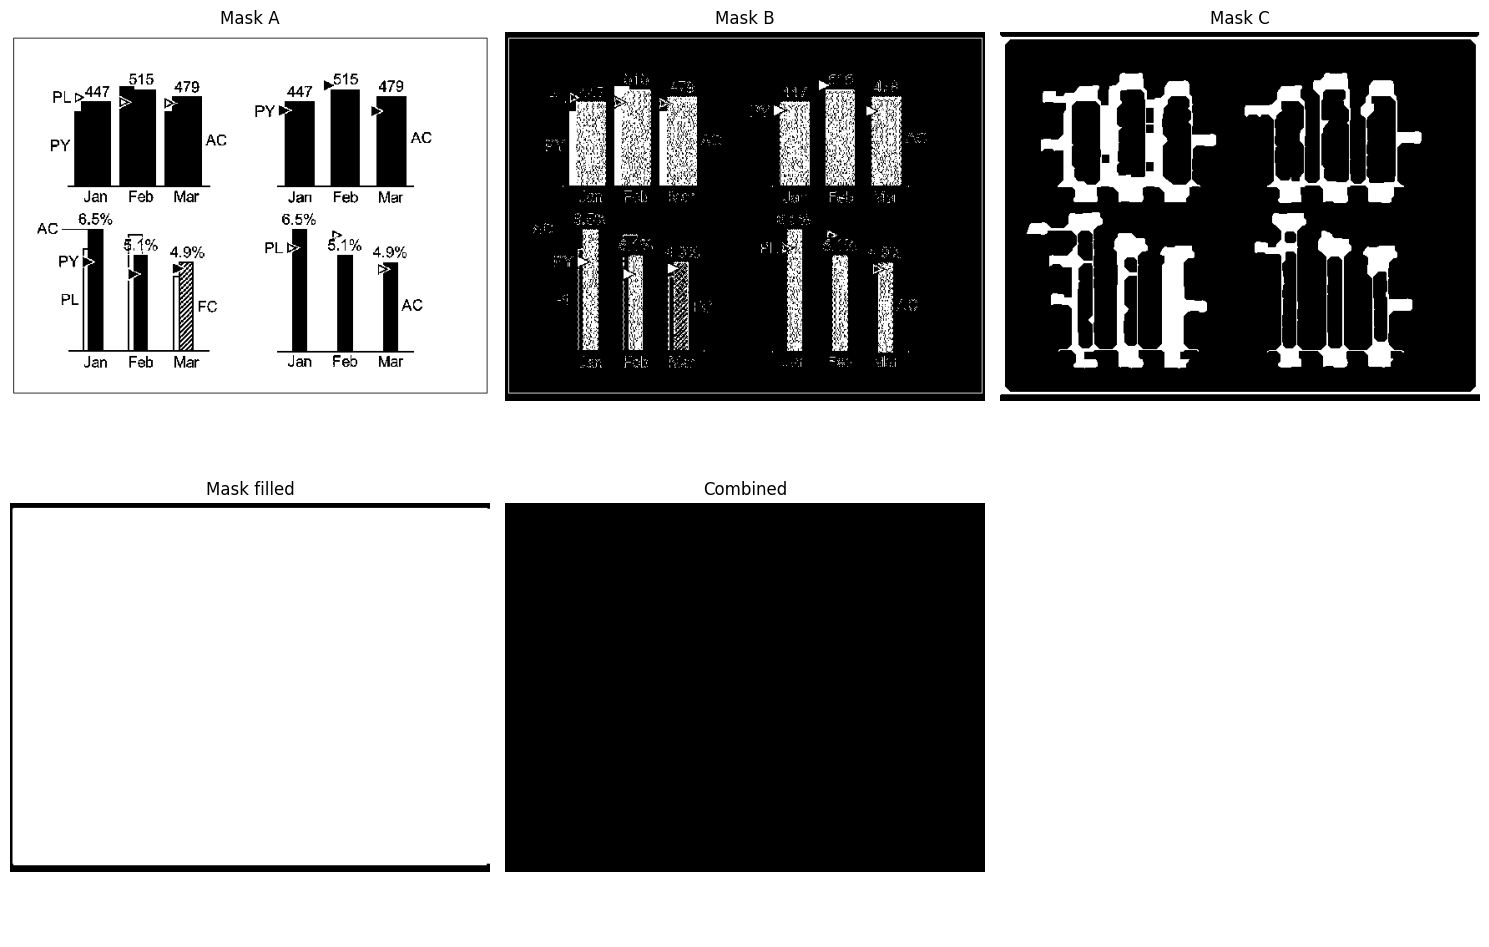

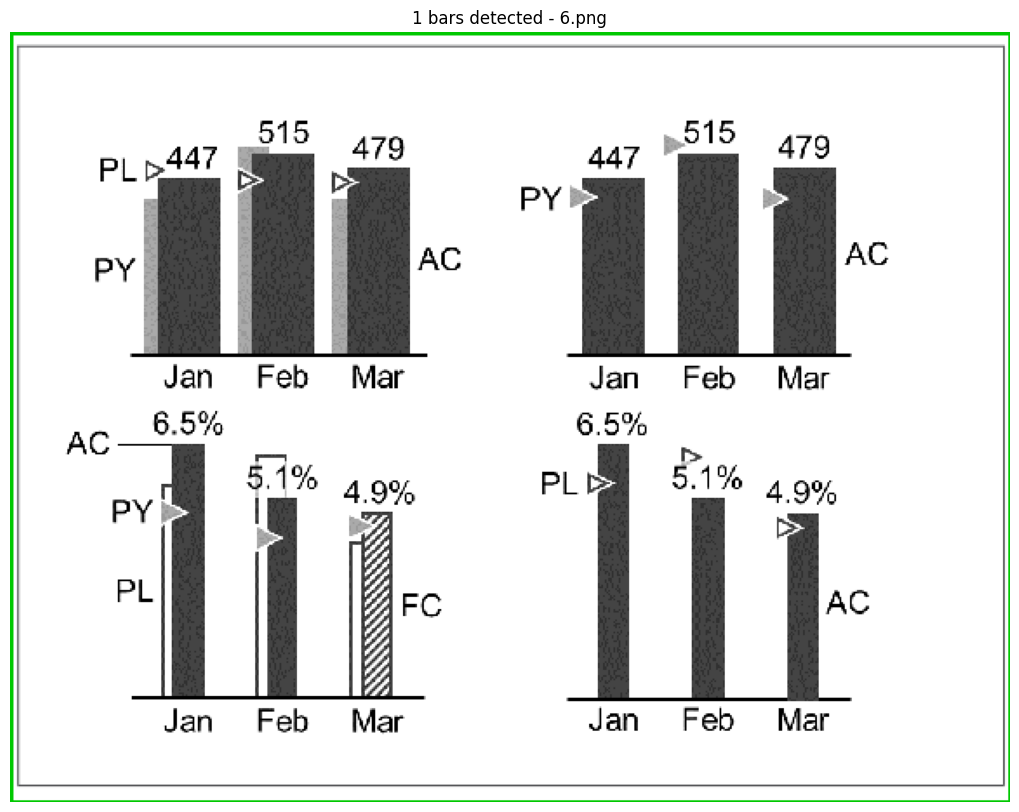

In [84]:
def detect_bars(
    image_path,
    invert_input=INVERT_INPUT,
    black_max=BLACK_MAX,
    grey_range=GREY_RANGE,
    canny_low=CANNY_LOW,
    canny_high=CANNY_HIGH,
    min_area_floor=MIN_AREA_FLOOR,
    min_area_fraction=MIN_AREA_FRACTION,
    min_fill_ratio=MIN_FILL_RATIO,
    min_bar_w=MIN_BAR_W,
    min_bar_h=MIN_BAR_H,
    max_aspect=MAX_ASPECT,
    show_steps=True,
):
    """Run the full pipeline on a single image and return bounding boxes.

    Returns a list of ``(x, y, w, h)`` tuples in pixel coordinates.
    When ``show_steps=True`` the intermediate masks and the final overlay
    are also rendered inline.
    """
    path = Path(image_path)
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(f"Could not read image: {path.resolve()}")
    rgb_img = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    gray_img = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    if invert_input:
        gray_img = cv2.bitwise_not(gray_img)

    _, m_a = cv2.threshold(gray_img, black_max, 255, cv2.THRESH_BINARY_INV)
    m_b = cv2.inRange(gray_img, grey_range[0], grey_range[1])

    edges_img = cv2.Canny(gray_img, canny_low, canny_high)
    d1 = np.array([[0, 0, 1], [0, 1, 0], [1, 0, 0]], dtype=np.uint8)
    d2 = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]], dtype=np.uint8)
    hatch = cv2.bitwise_or(
        cv2.morphologyEx(edges_img, cv2.MORPH_CLOSE, d1, iterations=3),
        cv2.morphologyEx(edges_img, cv2.MORPH_CLOSE, d2, iterations=3),
    )
    m_c = cv2.morphologyEx(
        hatch, cv2.MORPH_CLOSE,
        cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5)),
        iterations=2,
    )

    closed_edges = cv2.morphologyEx(
        edges_img, cv2.MORPH_CLOSE,
        cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3)),
        iterations=2,
    )
    contours_, _ = cv2.findContours(
        closed_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    kept_ = []
    for c in contours_:
        a = cv2.contourArea(c)
        if a < min_area_floor:
            continue
        p = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.04 * p, True)
        if not (4 <= len(approx) <= 8):
            continue
        x_, y_, w_, h_ = cv2.boundingRect(c)
        if a / max(w_ * h_, 1) < min_fill_ratio:
            continue
        kept_.append(c)
    m_filled = np.zeros_like(gray_img)
    cv2.drawContours(m_filled, kept_, -1, 255, thickness=-1)

    comb = cv2.bitwise_or(cv2.bitwise_or(m_a, m_b),
                          cv2.bitwise_or(m_c, m_filled))
    k = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    comb = cv2.morphologyEx(comb, cv2.MORPH_CLOSE, k, iterations=1)
    comb = cv2.morphologyEx(comb, cv2.MORPH_OPEN,  k, iterations=1)

    n, _, st, _ = cv2.connectedComponentsWithStats(comb, connectivity=8)
    candidates = []
    for i in range(1, n):
        x_, y_, w_, h_, a = st[i]
        if a < min_area_floor or w_ < min_bar_w or h_ < min_bar_h:
            continue
        if max(w_ / h_, h_ / w_) > max_aspect:
            continue
        if a / max(w_ * h_, 1) < min_fill_ratio:
            continue
        candidates.append((int(x_), int(y_), int(w_), int(h_), int(a)))

    if candidates:
        max_area = max(c[4] for c in candidates)
        dyn = max(min_area_floor, min_area_fraction * max_area)
        out = [(x_, y_, w_, h_) for x_, y_, w_, h_, a in candidates if a >= dyn]
    else:
        out = []

    if show_steps:
        show_grid(
            [m_a, m_b, m_c, m_filled, comb],
            ["Mask A", "Mask B", "Mask C", "Mask filled", "Combined"],
            cols=3, figsize=(15, 10),
        )
        ov = rgb_img.copy()
        for x_, y_, w_, h_ in out:
            cv2.rectangle(ov, (x_, y_), (x_ + w_, y_ + h_), (0, 200, 0), 2)
        show(ov, title=f"{len(out)} bars detected - {path.name}",
             figsize=(14, 10))

    return out


_ = detect_bars(IMAGE_PATH)